# Project 1: House Price Prediction

Welcome to your House Price Prediction project! In this project, we will use a **Linear Regression** model to predict house prices using the Boston Housing dataset.

### Project Roadmap:
1. **Step 1:** Import libraries and packages
2. **Step 2:** Load the Boston Housing dataset directly from the CMU data repository
3. **Step 3:** Exploratory Data Analysis (EDA) and Preprocessing
4. **Step 5:** Split the dataset into Training and Testing sets
5. **Step 5:** Train the Linear Regression Model
6. **Step 6:** Model Evaluation (RMSE, R²) & Coefficient Interpretation
7. **Step 7:** Save the Model and Make Example Predictions

## Step 1: Import Libraries

Let's import all the necessary libraries. Run the cell below to verify your python environment has all dependencies.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import pickle

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Boston Housing Dataset

Since `load_boston` was removed from scikit-learn >= 1.2, we will load the raw dataset directly from the official Carnegie Mellon University (CMU) repository:
`http://lib.stat.cmu.edu/datasets/boston`

In [20]:
# Fetching data directly from CMU url
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Combine split rows (since the data contains alternating rows of 11 and 3 features)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Define column feature names
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# Create DataFrame
df = pd.DataFrame(data, columns=feature_names)
# Add the target 'price' column
df['price'] = target

# Display the first few rows of the DataFrame
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## Step 3: Exploratory Data Analysis (EDA) & Preprocessing

Now that the dataset is loaded as a pandas DataFrame named `df`, let's inspect the data:
1. Check the shape (number of rows and columns).
2. Check for any missing (null) values.

In [21]:
# 1. Print the shape of the dataset
print("Shape of dataset:", df.shape)

# 2. Check for missing values in each column
print("Missing values check:")
print(df.isnull().sum())

Shape of dataset: (506, 14)
Missing values check:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
price      0
dtype: int64


Next, let's display the statistical summary of the dataset (mean, standard deviation, min, max, quartiles) to get a sense of the distribution of each feature.

In [22]:
# 3. Display summary statistics of the DataFrame
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Step 3.1: Feature Correlation

To build a good regression model, we want to know which features correlate strongly with our target column `price`.

We can build a **correlation heatmap** using `seaborn` to visualize how columns interact with each other (values near `1` indicate positive correlation, values near `-1` indicate negative correlation, and values near `0` indicate no correlation).

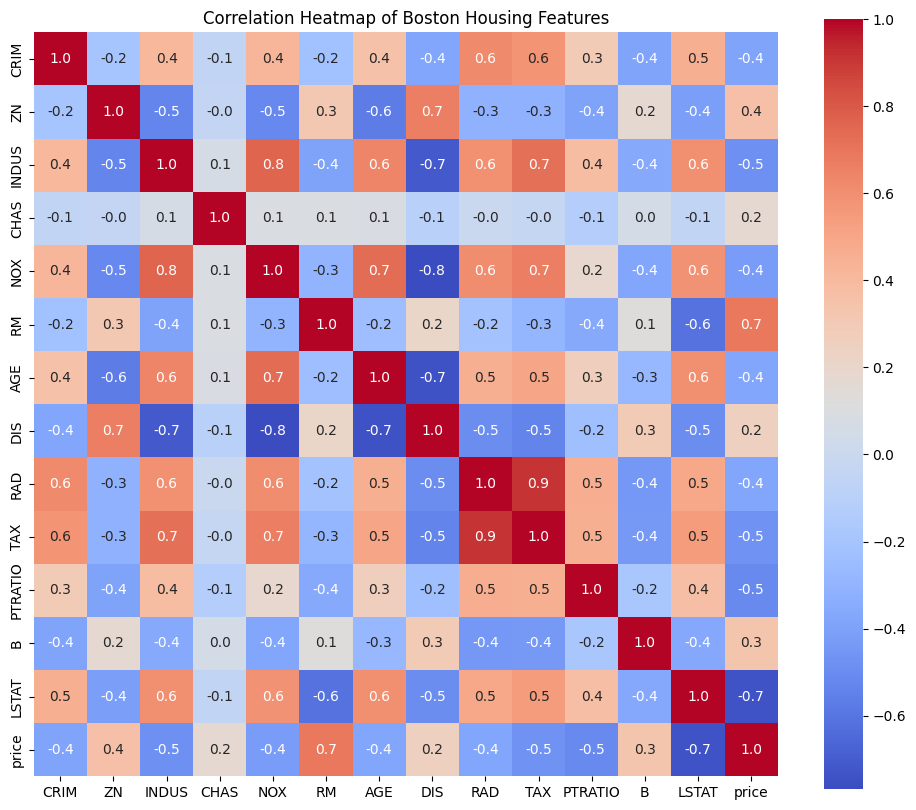

In [23]:
# Plot the correlation heatmap matrix
plt.figure(figsize=(12, 10))

# Calculate the correlation matrix from df and plot using sns.heatmap
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".1f", cmap="coolwarm", square=True)

plt.title("Correlation Heatmap of Boston Housing Features")
plt.show()

### Step 3.2: Visualizing Key Relationships

From the heatmap, you should notice two features with a strong correlation to `price`:
* **`RM`** (Average number of rooms per dwelling) has a strong **positive** correlation with price.
* **`LSTAT`** (% lower status of the population) has a strong **negative** correlation with price.

Let's create two scatter plots to visualize these relationships.

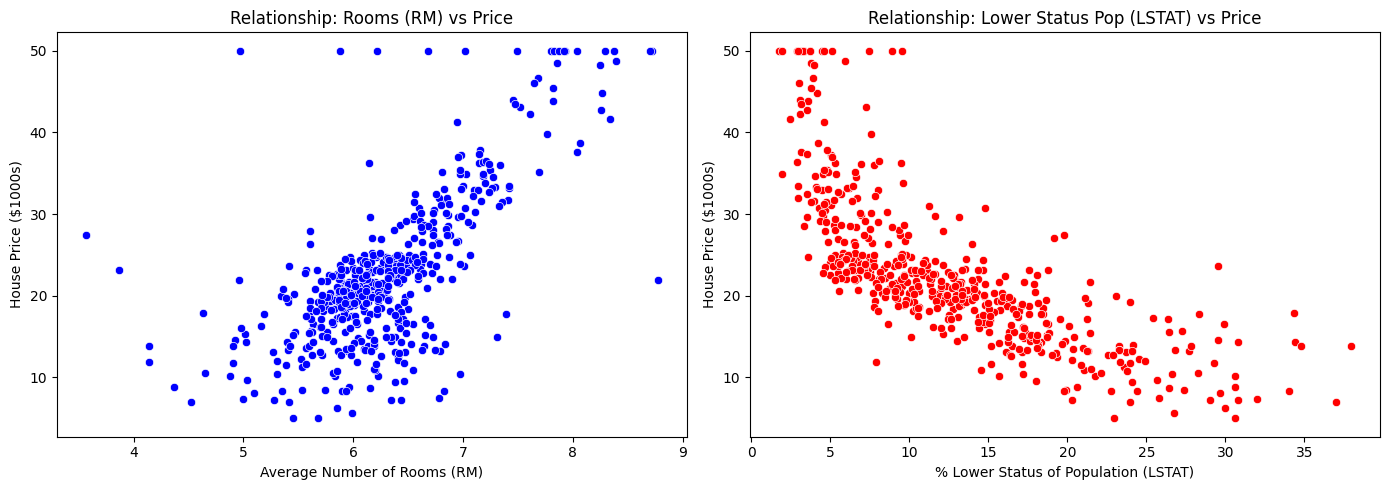

In [24]:
# Set up figure size
plt.figure(figsize=(14, 5))

# Subplot 1: Rooms (RM) vs Price
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['RM'], y=df['price'], color='blue')
plt.title('Relationship: Rooms (RM) vs Price')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('House Price ($1000s)')

# Subplot 2: Lower Status Population (LSTAT) vs Price
plt.subplot(1, 2, 2)
sns.scatterplot(x=df['LSTAT'], y=df['price'], color='red')
plt.title('Relationship: Lower Status Pop (LSTAT) vs Price')
plt.xlabel('% Lower Status of Population (LSTAT)')
plt.ylabel('House Price ($1000s)')

plt.tight_layout()
plt.show()

## Step 4: Split the Dataset into Training and Testing Sets

To validate how well our model performs on unseen data, we must separate our dataset:
1. **`X` (Features)**: All columns except the target `price` column.
2. **`Y` (Target)**: Just the `price` column.

Then, we split `X` and `Y` into train and test sets using the `train_test_split` function. We will use a standard split ratio:
* **80%** of the data for training (`test_size=0.2`)
* **20%** of the data for testing

In [25]:
# 1. Separate features (X) and target (Y)
X = df.drop(columns=['price'])
Y = df['price']

# 2. Split X and Y into training and testing sets (use test_size=0.2 and random_state=2 for reproducible results)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 3. Print the shapes of the split datasets to verify they match
print("Original features shape:", X.shape)
print("Train features shape:", X_train.shape)
print("Test features shape:", X_test.shape)


Original features shape: (506, 13)
Train features shape: (404, 13)
Test features shape: (102, 13)


## Step 5: Train the Linear Regression Model

Now, we will train our **Linear Regression** model using the training data:
1. Instantiate the model: `model = LinearRegression()`
2. Fit (train) the model on `X_train` and `Y_train`.

In [26]:
# 1. Instantiate the Linear Regression model
model = LinearRegression()

# 2. Train the model using the training datasets
model.fit(X_train, Y_train)

print("Model training completed successfully!")

Model training completed successfully!


## Step 6: Model Evaluation (RMSE & R²) & Coefficient Interpretation

To evaluate how well our model fits the data, we will calculate the evaluation metrics requested in the project specifications:
1. **Root Mean Squared Error (RMSE)**: Tells us the average prediction error (in target units).
2. **R² (R-squared) Score**: Tells us the proportion of variance in the target that is predictable from the features (scores closer to `1` indicate a better model fit).

Let's write a code cell to make predictions on both the training set and testing set and compute these values.

In [27]:
# 1. Make predictions on Training and Testing sets
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# 2. Calculate RMSE for Train and Test sets
train_rmse = np.sqrt(metrics.mean_squared_error(Y_train, train_preds))
test_rmse = np.sqrt(metrics.mean_squared_error(Y_test, test_preds))

# 3. Calculate R2 score for Train and Test sets
train_r2 = metrics.r2_score(Y_train, train_preds)
test_r2 = metrics.r2_score(Y_test, test_preds)

# Print training evaluation metrics
print("========== Training Set Metrics ==========")
print(f"RMSE: {train_rmse:.3f}")
print(f"R2 Score: {train_r2:.3f}")

# Print testing evaluation metrics
print("\n========== Testing Set Metrics ==========")
print(f"RMSE: {test_rmse:.3f}")
print(f"R2 Score: {test_r2:.3f}")

========== Training Set Metrics ==========
RMSE: 4.791
R2 Score: 0.729

========== Testing Set Metrics ==========
RMSE: 4.301
R2 Score: 0.779


### Step 6.1: Coefficient Interpretation

In a Linear Regression model, the coefficients represent how much the target variable (`price`) changes for a one-unit change in an input feature, keeping all other features constant.

Let's map our features to the model's coefficients (`model.coef_`) and print them in a table.

In [28]:
# Print intercept
print(f"Intercept (b): {model.intercept_:.3f}\n")

# Map feature names to coefficients
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df.sort_values(by='Coefficient', ascending=False)

Intercept (b): 37.200



,Coefficient
RM,3.632885
CHAS,3.158979
RAD,0.324066
ZN,0.038904
B,0.011613
AGE,0.009351
TAX,-0.011625
INDUS,-0.015152
CRIM,-0.108224
LSTAT,-0.558409


## Step 7: Save the Model and Make Example Predictions

To deploy our trained model, we can save it to a file using Python's built-in `pickle` library.
This allows us to load the model later and make predictions on new data without needing to retrain it.

In [29]:
# 1. Save the model to a file named 'linear_regression_model.pkl'
with open('linear_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully to 'linear_regression_model.pkl'!")

Model saved successfully to 'linear_regression_model.pkl'!


In [30]:
# 2. Load the saved model and predict the price for a new sample house
with open('linear_regression_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Let's define a sample house with average features (same structure as X columns)
# features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
sample_house = np.array([[0.006, 18.0, 2.31, 0.0, 0.538, 6.575, 65.2, 4.09, 1.0, 296.0, 15.3, 396.9, 4.98]])

# Predict the house price
predicted_value = loaded_model.predict(sample_house)

# The prices in the dataset are in thousands of dollars ($1,000s)
print(f"Predicted House Value: ${predicted_value[0]:.2f} thousand (which is ${predicted_value[0]*1000:,.2f})")

Predicted House Value: $30.62 thousand (which is $30,621.73)


c:\Users\Yassin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
